# HMM-Diffusion

Regime-conditional synthetic financial time series. Volatility regimes are detected on S&P 500 total return (A001) log returns, one diffusion specialist is trained per regime, and an HMM estimates the regime path used to stitch specialist output into a single series.

Vol_Regime is run on A001 over **2001-01-01 to 2022-08-31**. The HMM is trained on **2001-01-01 to 2014-01-03**. **2014-01-06 to 2022-08-31** is held out as the test set. There is no validation slice.

Diffusion specialists generate 10-asset windows, labeled by the A001 regimes, and are trained on the full 2001–2022 overlap. The HMM is still trained only on 2001–2014.

This notebook follows the Supervised HMMs pipeline with the GAN replaced by diffusion. Four HMM variants are fit and compared: supervised, Markov switching, semi-supervised, and neural.

The HMM is not the generator. It supplies a regime path, and each step selects which specialist pool the next value is drawn from. We measure how well specialists reproduce their regime's return distribution and how well the HMM recovers the regime path from emissions alone.

Run scripts 01 through 04 before this notebook (relabel with `python scripts/01_label_regimes.py --force` after the 2001 calendar change). Without stages 3 and 4 the notebook uses placeholder pools resampled from real returns. Every cell still runs, but generated-data results are not from diffusion.


In [14]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config()
bootstrap_imports()  # puts reference_model/hmmgan and reference_model/diffusion on sys.path

from hmmdiff import data, models, plots, pools, regimes, stitch

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_REGIMES = cfg["regimes"]["n_regimes"]
TOP_K = cfg["hmm"]["top_k"]
REFERENCE = cfg["reference"]

print(f"{N_REGIMES} regimes, seq_len {cfg['diffusion']['seq_len']}")

5 regimes, seq_len 128


## Data preparation

S&P 500 total return closing prices are converted to log returns and standardized on **2001-01-01 to 2022-08-31**. Train is through 2014-01-03; test starts 2014-01-06. The HMM uses the full train slice; there is no inner train/validation split.


returns        9031  1988-01-20 to 2022-08-31
train / test   6773 / 2258
inner / val    5079 / 1694


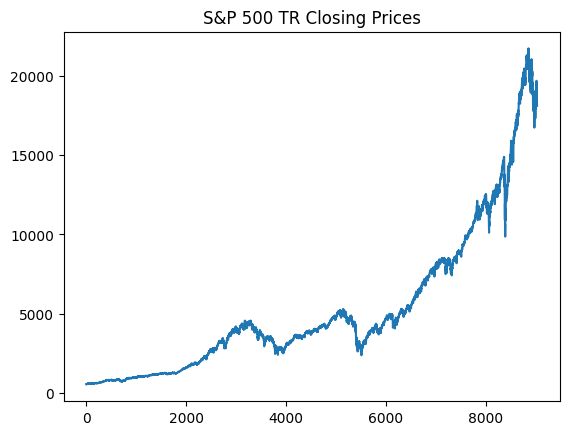

In [15]:
returns = data.load_returns(cfg)
counts = data.split_counts(returns)
train_series, test_series = data.split_series(returns)

print(f"returns      {counts['n_returns']:>6}  {counts['start_date']} to {counts['end_date']}")
print(f"train / test {counts['n_train']:>6} / {counts['n_test']}")
print(f"train end    {counts['train_end_date']}    test start {counts['test_start_date']}")

assert counts["n_returns"] == REFERENCE["n_returns"]
assert counts["n_train"] == REFERENCE["n_train"]
assert counts["n_test"] == REFERENCE["n_test"]
assert counts["start_date"] == REFERENCE["start_date"]
assert counts["train_end_date"] == REFERENCE["train_end_date"]
assert counts["test_start_date"] == REFERENCE["test_start_date"]

plots.plot_prices(returns["z_return"].to_numpy(dtype=float), title="A001 standardized return")


## Volatility regimes

Labels are loaded from the cache written by `scripts/01_label_regimes.py`. Clustering uses the **full** 2001–2022 A001 series. Labels are reordered so regime index increases with variance. Plots below show the full labeled series; the HMM is fit only on the train dates.


,n_days,mean,variance
regime,,,
0,1345,0.0075,0.2506
1,2333,0.0195,0.4515
2,1920,-0.0027,1.4422
3,995,-0.0418,1.9043
4,180,-0.0776,4.1038


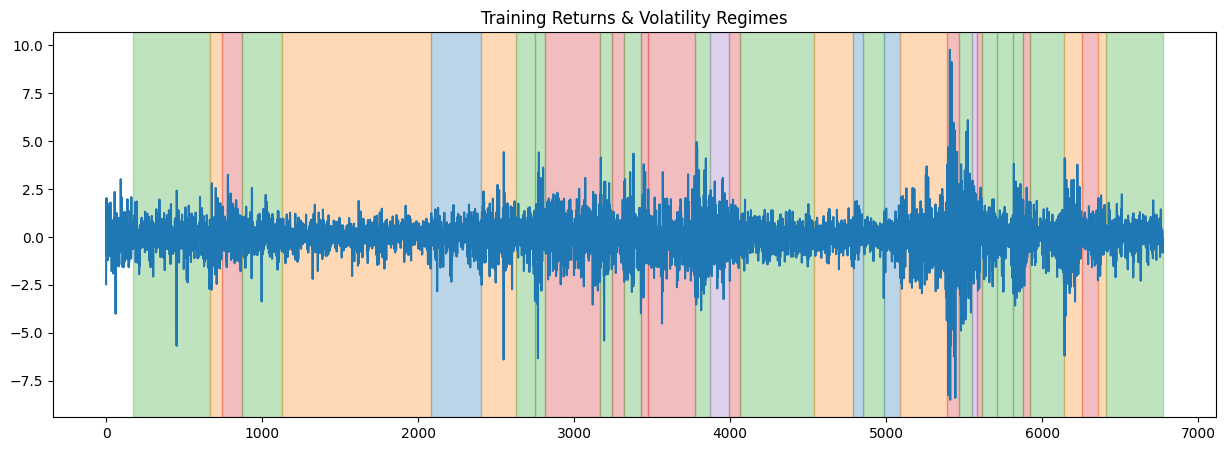

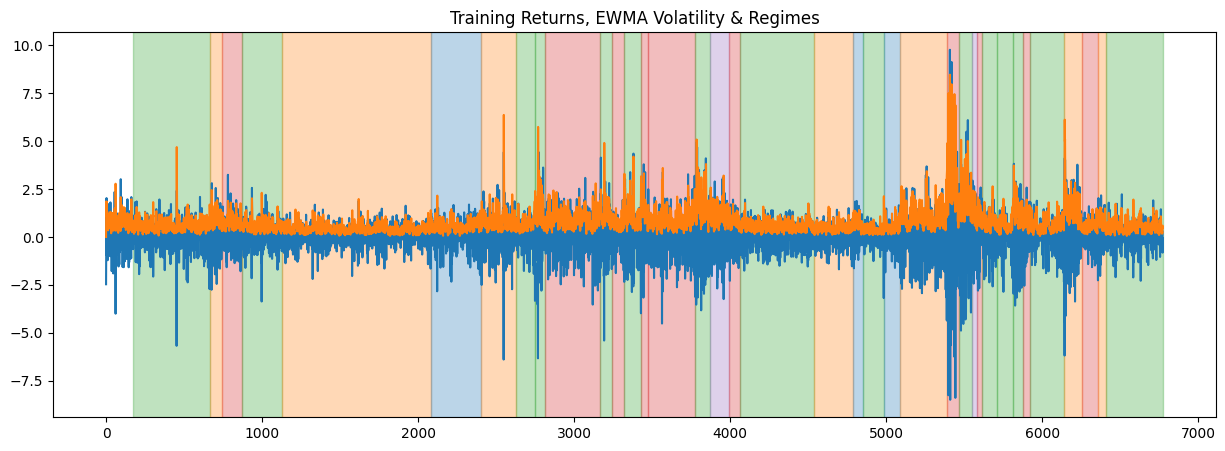

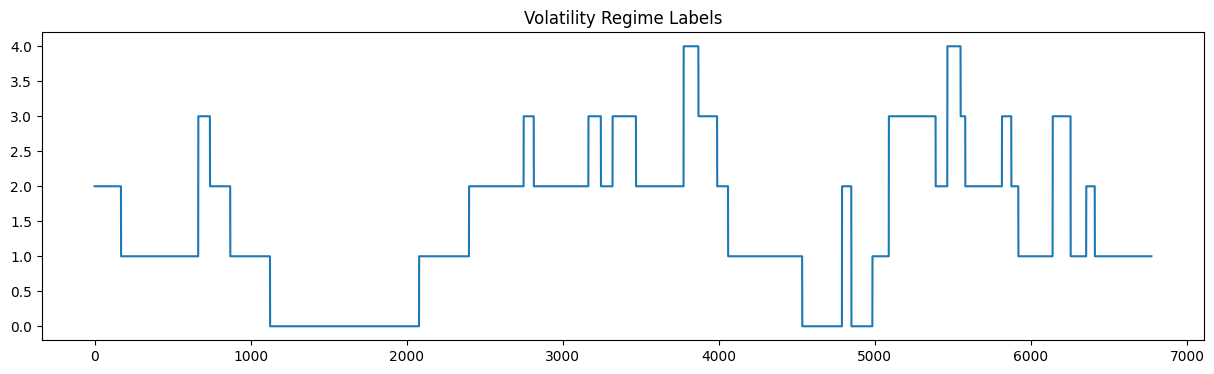

In [16]:
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)
train_labels, test_labels = data.split_labels(returns, regime_labels)
segment_colors = labels.segment_colors()

print(f"labels {len(regime_labels)} days  train {len(train_labels)}  test {len(test_labels)}")
display(plots.regime_moments(returns["z_return"].to_numpy(dtype=float), regime_labels, N_REGIMES))

plots.plot_regime_spans(
    returns["z_return"].to_numpy(dtype=float),
    labels.changepoints,
    segment_colors,
    title="A001 Returns & Volatility Regimes (2001–2022)",
)
plots.plot_regime_spans(
    returns["z_return"].to_numpy(dtype=float),
    labels.changepoints,
    segment_colors,
    overlay=regimes.ewm_volatility(returns["z_return"].to_numpy(dtype=float), cfg["regimes"]["ewm_com"]),
    title="A001 Returns, EWMA Volatility & Regimes",
)
plots.plot_regime_labels(regime_labels)


## Model frames and transition structure

`train_data` is 2001–2014 and `test_data` is 2014–2022. Each frame holds the A001 regime label, the A001 emission, and the lagged emission for the Markov switching variant. The empirical transition matrix below is estimated on the train labels, which is the path the HMM is trained against.


In [17]:
train_data, test_data = data.build_model_frames(returns, regime_labels, cfg)

coverage = pd.DataFrame(
    {
        "train": np.bincount(train_data.regime.values, minlength=N_REGIMES),
        "test": np.bincount(test_data.regime.values, minlength=N_REGIMES),
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(coverage)

missing_train = coverage.index[coverage["train"] == 0].tolist()
assert not missing_train, (
    f"Regimes {missing_train} are absent from the training slice, so their emission parameters "
    "would come from the prior. Re-run scripts/01_label_regimes.py with a different "
    "regimes.changepoint_penalty."
)
missing_test = coverage.index[coverage["test"] == 0].tolist()
if missing_test:
    print(
        f"Note: regimes {missing_test} do not occur in the test slice, so test accuracy "
        "is measured over the remaining regimes only."
    )


,train,val
regime,,
0,1345,0
1,1639,694
2,1510,410
3,490,505
4,95,85


Note: regimes [0] do not occur in the validation slice, so validation accuracy is measured over the remaining regimes only.


In [18]:
empirical_transmat = regimes.empirical_transition_matrix(regime_labels, N_REGIMES)
outbound_transmat = regimes.outbound_transition_matrix(empirical_transmat, N_REGIMES)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")

print("Empirical transition matrix")
display(pd.DataFrame(empirical_transmat, index=index, columns=columns))

print("Outbound transition matrix (diagonal removed, rows renormalized)")
display(pd.DataFrame(outbound_transmat, index=index, columns=columns))

print("Average consecutive days per visit")
display(pd.Series(regimes.average_regime_length(regime_labels)).sort_index())

Empirical transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9978,0.0015,0.0007,0.0000,0.0000
1,0.0009,0.9970,0.0009,0.0013,0.0000
2,0.0005,0.0026,0.9938,0.0021,0.0010
3,0.0000,0.0010,0.0080,0.9910,0.0000
4,0.0000,0.0000,0.0000,0.0111,0.9889


Outbound transition matrix (diagonal removed, rows renormalized)


to,0,1,2,3,4
from,,,,,
0,0.0000,0.6667,0.3333,0.0000,0.0000
1,0.2857,0.0000,0.2857,0.4286,0.0000
2,0.0833,0.4167,0.0000,0.3333,0.1667
3,0.0000,0.1111,0.8889,0.0000,0.0000
4,0.0000,0.0000,0.0000,1.0000,0.0000


Average consecutive days per visit


0   448.3333
1   291.6250
2   160.0000
3   110.5556
4    90.0000
dtype: float64

## Diffusion pools

One pool of synthetic 128-day windows per regime, produced by that regime's specialist. Each pool is flattened into a sequence. Stitching walks a regime path and takes the next unused value from the matching pool. If specialists are not trained yet, placeholder pools resampled from real per-regime returns are used instead.


In [19]:
pools_root = config_path(cfg, "pools")
USING_PLACEHOLDER = not pools.pools_available(pools_root, N_REGIMES)
GENERATED_TITLE = (
    "PLACEHOLDER: Resampled Real Returns (not diffusion)"
    if USING_PLACEHOLDER
    else "HMM Diffusion Generated Returns"
)

if USING_PLACEHOLDER:
    print(
        "WARNING: no trained specialist pools found under "
        f"{pools_root.relative_to(REPO_ROOT)}.\n"
        "Falling back to placeholder pools resampled from the real per-regime returns.\n"
        "Run scripts/03_train_specialists.sh and scripts/04_generate_pools.py for real results."
    )
    generated_images = pools.placeholder_pools(
        train_series, train_labels, N_REGIMES, size=len(train_series), seed=0
    )
else:
    regime_stats = pools.regime_emission_stats(
        train_data.emission.values, train_data.regime.values, N_REGIMES
    )
    generated_images = pools.load_generated_images(
        pools_root,
        N_REGIMES,
        returns=returns,
        calibrate_regimes=regime_stats,
    )
    mu, sd = data.a001_log_return_scale(returns)
    print(f"Pool A001 rescaled: global z-score (mu={mu:.6e}, sd={sd:.6e}) + per-regime calibration")
    for k in range(N_REGIMES):
        meta = pools.load_pool_meta(pools_root, k)
        print(f"regime {k}: {meta.get('n_pool')} windows from {Path(meta.get('checkpoint_dir', '')).name}")

pool_summary = pd.DataFrame(
    {
        "pool_length": [generated_images[str(k)].size for k in range(N_REGIMES)],
        "pool_mean": [generated_images[str(k)].mean() for k in range(N_REGIMES)],
        "pool_var": [generated_images[str(k)].var() for k in range(N_REGIMES)],
        "real_mean": [train_series[train_labels == k].mean() for k in range(N_REGIMES)],
        "real_var": [train_series[train_labels == k].var() for k in range(N_REGIMES)],
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(pool_summary)

# Every regime path that will be stitched below, so pool sufficiency is checked up front rather
# than failing partway through a variant.
candidate_paths = [train_data.regime.values, test_data.regime.values]
problems, _ = pools.check_pools(
    generated_images, candidate_paths, train_series, train_labels, N_REGIMES
)
for problem in problems:
    print(f"POOL CHECK: {problem}")
if not problems:
    print("Pool checks passed: finite, sufficient for every regime path, variance ordering matches.")


Pool A001 rescaled: global z-score (mu=3.890171e-04, sd=1.117219e-02) + per-regime calibration
regime 0: 128 windows from diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_0
regime 1: 128 windows from diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_1
regime 2: 128 windows from diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_2
regime 3: 128 windows from diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_3
regime 4: 128 windows from diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_4


,pool_length,pool_mean,pool_var,real_mean,real_var
regime,,,,,
0,16384,0.0075,0.2506,0.0075,0.2506
1,16384,0.0192,0.4566,0.0195,0.4515
2,16384,0.0044,0.9389,-0.0027,1.4422
3,16384,-0.0307,1.8801,-0.0418,1.9043
4,16384,-0.0860,3.6063,-0.0776,4.1038


Pool checks passed: finite, sufficient for every regime path, variance ordering matches.


## HMM variants

Four ways of estimating a transition matrix and per-regime Gaussian emission parameters. Supervised HMM treats regimes and emissions as observed and is fit with NUTS. Markov switching regresses the emission mean on the previous emission. Semi-supervised keeps labels on the first half of training and treats the second half as unlabeled. Neural HMM uses a small network for emission parameters fit by SVI.

All four are evaluated the same way: forward-backward smoothing, comparison to true labels, stitching along the estimated path, and per-regime moment tables. Top-2 accuracy is reported alongside top-1 because adjacent volatility regimes overlap heavily.


In [20]:
init_dist = models.initial_distribution(train_data, N_REGIMES)


def evaluate_variant(key, fit):
    """Fit diagnostics, state estimation, stitching, and plots for one HMM variant."""
    print("=" * 78)
    print(fit.name)
    print("=" * 78)

    print("Posterior transition matrix")
    display(pd.DataFrame(fit.transmat.round(3), index=index, columns=columns))
    print("Emission parameters")
    display(fit.summary())

    train_probs, train_est = models.estimate_states(
        fit, train_data.emission.values, init_dist, N_REGIMES
    )
    test_probs, test_est = models.estimate_states(
        fit, test_data.emission.values, init_dist, N_REGIMES
    )
    train_acc = models.accuracy_report(
        train_data.regime.values, train_est, train_probs, N_REGIMES, TOP_K
    )
    test_acc = models.accuracy_report(
        test_data.regime.values, test_est, test_probs, N_REGIMES, TOP_K
    )

    print(
        f"Train accuracy {train_acc['accuracy']:>7.2%}   "
        f"top-{TOP_K} {train_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
    )
    print(
        f"Test  accuracy {test_acc['accuracy']:>7.2%}   "
        f"top-{TOP_K} {test_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
    )

    plots.plot_estimates(train_est, train_data.regime.values, f"{fit.name}: Train")
    plots.plot_estimates(test_est, test_data.regime.values, f"{fit.name}: Test")

    oracle = stitch.stitch(generated_images, train_data.regime.values)
    estimated, test_estimated = plots.plot_paper_train_test(
        train_data.emission.values,
        train_data.regime.values,
        train_est,
        test_data.emission.values,
        test_data.regime.values,
        test_est,
        generated_images,
        generated_title=GENERATED_TITLE,
    )

    table = stitch.backtest_table(
        train_data.emission.values,
        train_data.regime.values,
        estimated,
        train_est,
        N_REGIMES,
    )
    test_table = stitch.backtest_table(
        test_data.emission.values,
        test_data.regime.values,
        test_estimated,
        test_est,
        N_REGIMES,
    )
    print("Train backtest")
    display(table)
    print("Test backtest")
    display(test_table)

    return {
        "name": fit.name,
        "fit": fit,
        "train_accuracy": train_acc["accuracy"],
        "train_top_k": train_acc[f"top_{TOP_K}_accuracy"],
        "test_accuracy": test_acc["accuracy"],
        "test_top_k": test_acc[f"top_{TOP_K}_accuracy"],
        "oracle": oracle,
        "estimated": estimated,
        "test_estimated": test_estimated,
        "backtest": table,
        "test_backtest": test_table,
    }


results = {}


sample: 100%|██████████| 300/300 [00:13<00:00, 22.73it/s, 31 steps of size 1.72e-01. acc. prob=0.84] 

Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0020,0.0010,0.0000,0.0000
1,0.0010,0.9970,0.0010,0.0010,0.0000
2,0.0010,0.0020,0.9940,0.0020,0.0010
3,0.0000,0.0000,0.0110,0.9880,0.0000
4,0.0020,0.0010,0.0020,0.0120,0.9830


Emission parameters


,mean,sigma
regime,,
0,0.0087,0.5028
1,0.0202,0.6764
2,0.0043,0.9672
3,-0.0383,1.3822
4,-0.0355,1.9231


100%|██████████| 5079/5079 [00:00<00:00, 96240.66it/s]
5079it [00:00, 96527.60it/s]
100%|██████████| 1694/1694 [00:00<00:00, 97424.26it/s]
1694it [00:00, 96855.84it/s]


Train accuracy  83.40%   top-2  96.69%
Val   accuracy  63.40%   top-2  90.50%


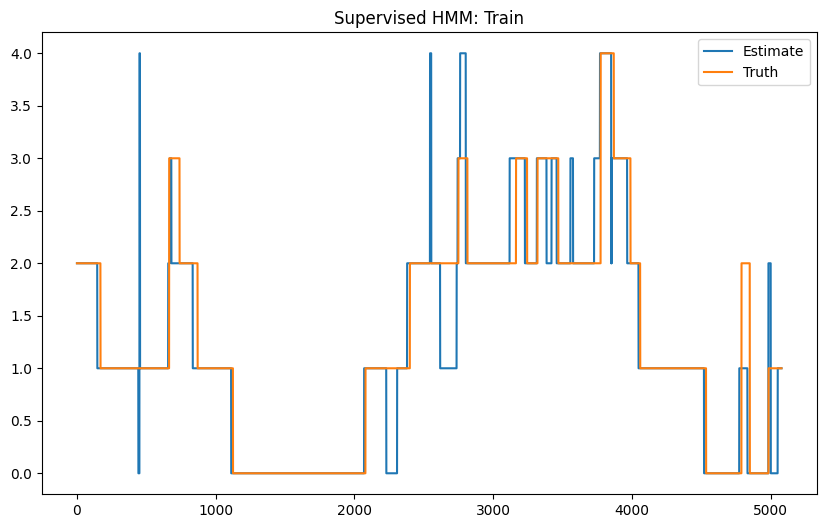

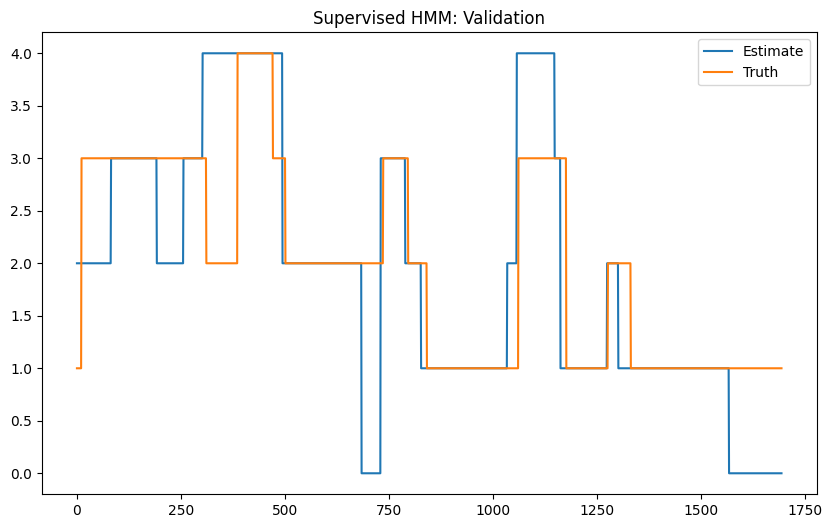

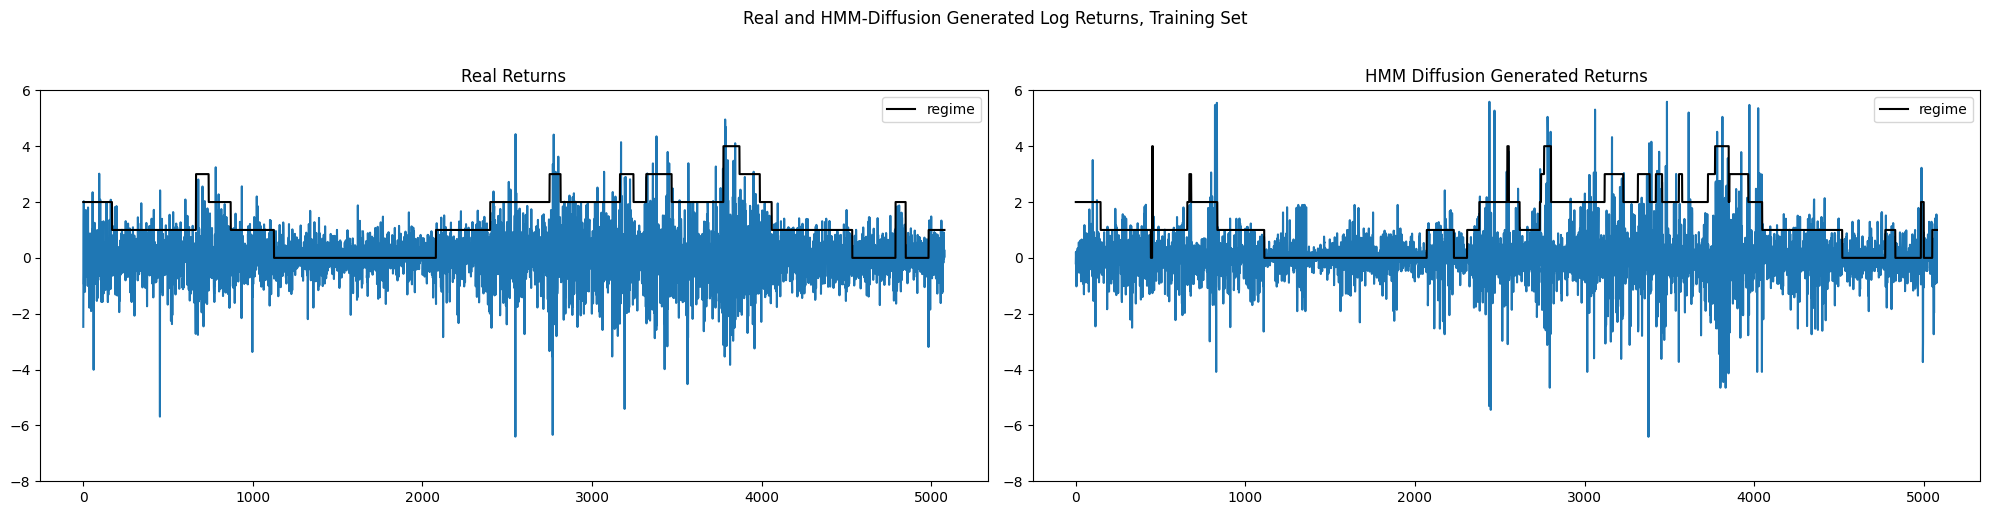

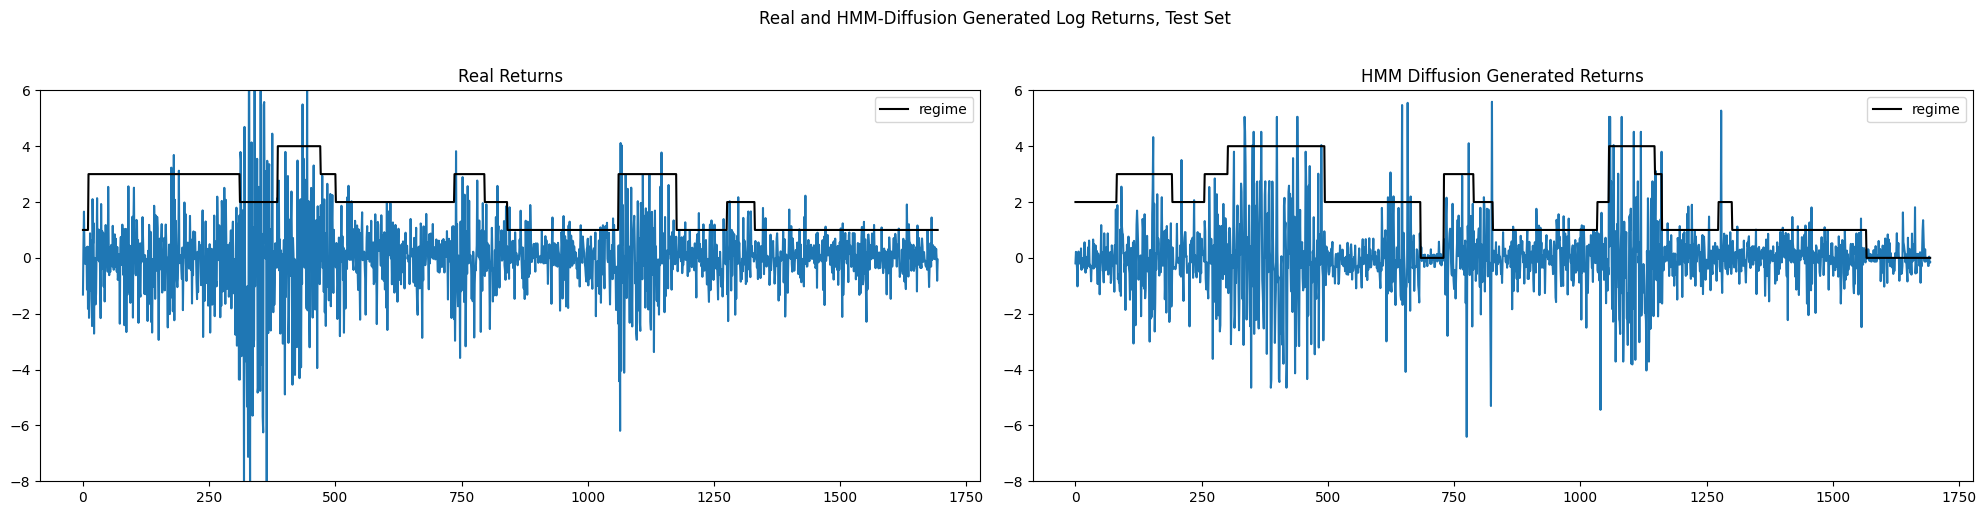

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1345,0.0075,0.0073,0.2508,0.2733
1,1639,0.0192,0.0063,0.4569,0.4725
2,1510,0.0044,-0.0277,0.9395,0.9034
3,490,-0.0307,-0.0373,1.8839,1.6004
4,95,-0.0860,-0.1742,3.6447,4.3836


Test (validation) backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,0,NaN,NaN,NaN,NaN
1,694,0.0202,0.0221,0.4401,0.5017
2,410,-0.0289,0.0425,3.3034,1.6855
3,505,-0.0527,-0.0845,1.9314,1.8276
4,85,-0.0683,-0.2607,4.7152,5.3785


In [21]:
results["supervised"] = evaluate_variant(
    "supervised", models.fit_supervised_hmm(train_data, N_REGIMES, cfg)
)

sample: 100%|██████████| 300/300 [00:15<00:00, 19.95it/s, 15 steps of size 1.86e-01. acc. prob=0.92] 

Markov Switching Model
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9960,0.0020,0.0020,0.0000,0.0000
1,0.0010,0.9970,0.0010,0.0010,0.0000
2,0.0010,0.0020,0.9940,0.0020,0.0010
3,0.0000,0.0000,0.0100,0.9880,0.0010
4,0.0020,0.0020,0.0020,0.0130,0.9800


Emission parameters


,mean,sigma
regime,,
0,0.0082,0.5006
1,0.0186,0.6776
2,0.0051,0.9688
3,-0.0314,1.3742
4,-0.0594,1.9226


100%|██████████| 5079/5079 [00:00<00:00, 96328.13it/s]
5079it [00:00, 97107.54it/s]
100%|██████████| 1694/1694 [00:00<00:00, 95966.27it/s]
1694it [00:00, 96249.67it/s]


Train accuracy  83.23%   top-2  96.65%
Val   accuracy  64.99%   top-2  91.15%


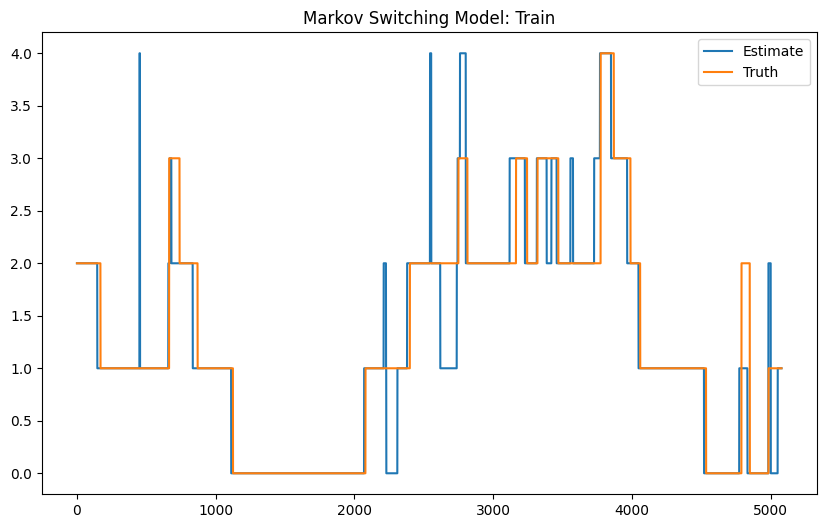

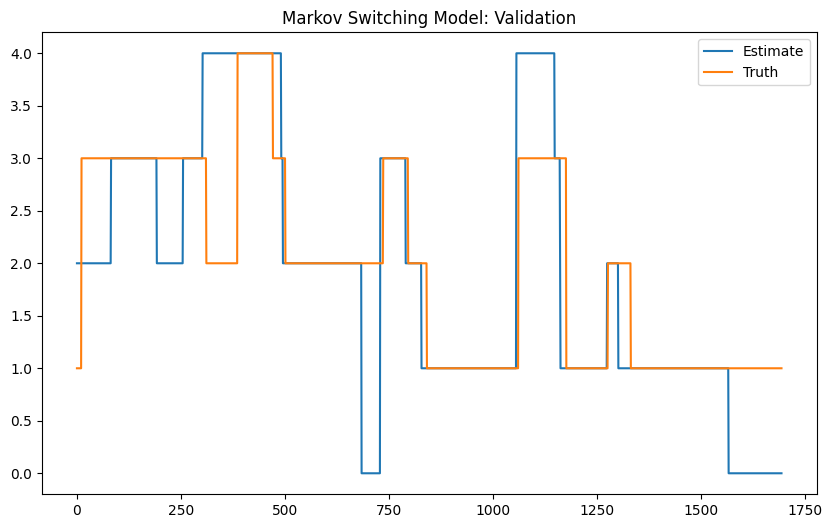

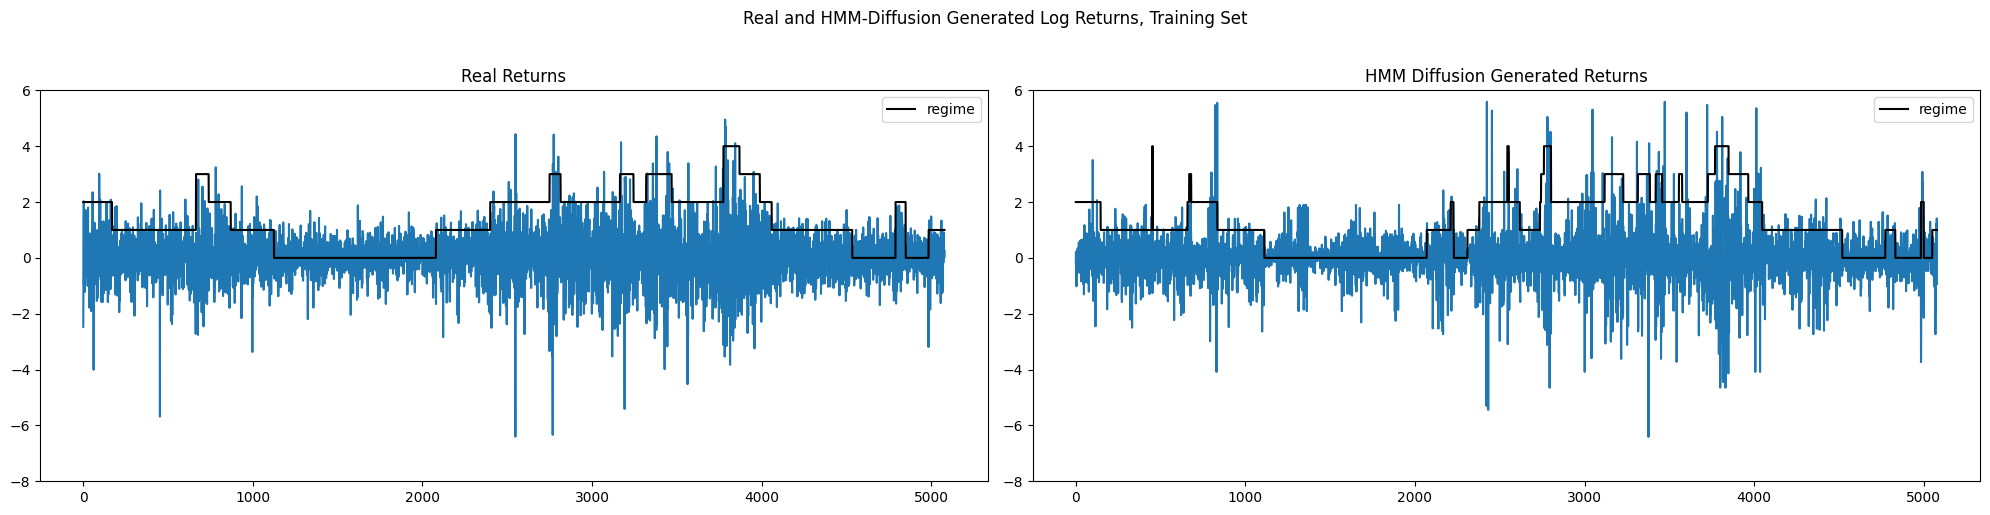

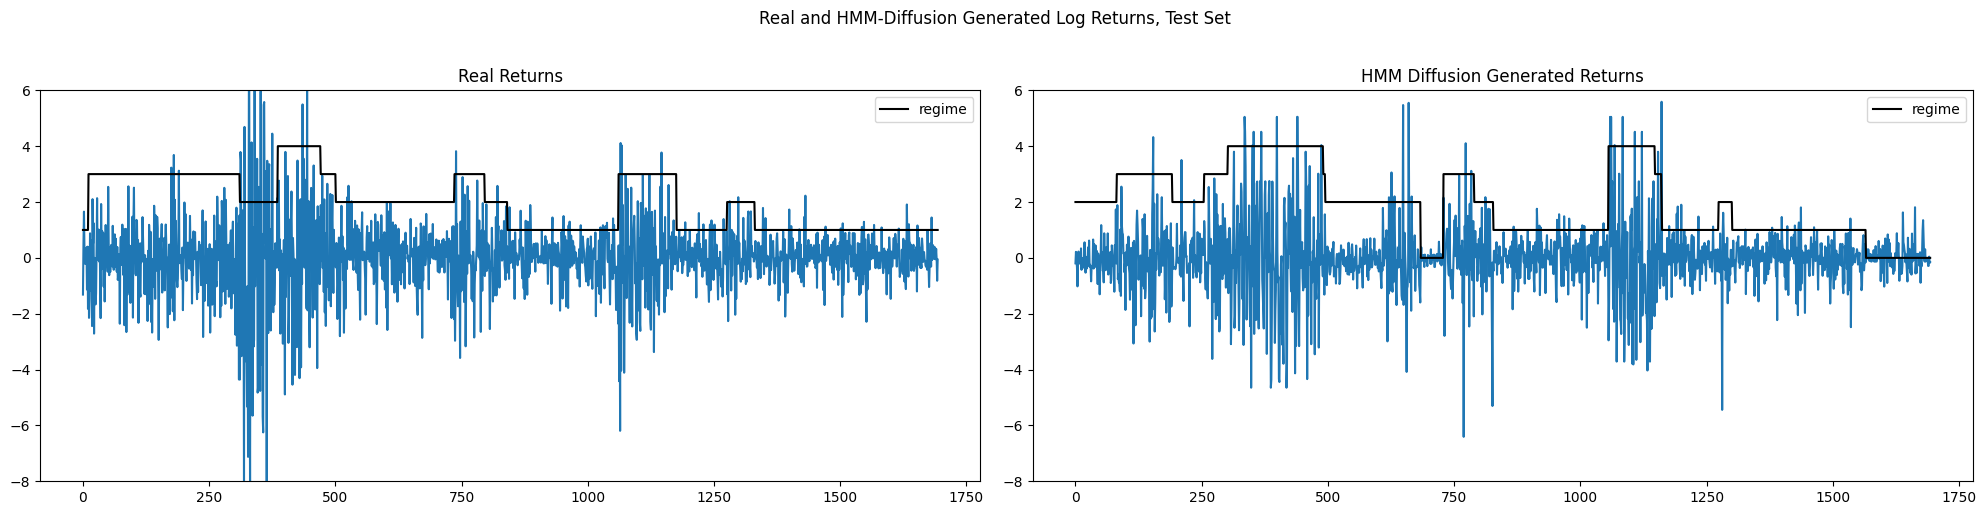

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1345,0.0075,0.0077,0.2508,0.2774
1,1639,0.0192,0.0047,0.4569,0.4662
2,1510,0.0044,-0.0214,0.9395,0.9477
3,490,-0.0307,-0.0441,1.8839,1.5275
4,95,-0.0860,-0.2315,3.6447,4.2855


Test (validation) backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,0,NaN,NaN,NaN,NaN
1,694,0.0202,0.0143,0.4401,0.4201
2,410,-0.0289,0.0019,3.3034,1.6456
3,505,-0.0527,-0.0482,1.9314,1.9258
4,85,-0.0683,-0.2607,4.7152,5.3785


In [22]:
results["markov_switching"] = evaluate_variant(
    "markov_switching", models.fit_markov_switching(train_data, N_REGIMES, cfg)
)

[ -0.8692968 -37.921055  -38.303455   -1.901582   -2.6670055]
(2539,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891284]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2733107]
 [-0.4881314 -1.81827   -2.438177  -2.2725506 -3.394642 ]
 [-2.8772955 -2.5834103 -2.6981206 -0.8134196 -1.0285479]]
loc
[-0.27706242 -1.3087606   1.4700975  -1.1474452   0.5143523 ]
(5,)
[0.28611243 0.16749428 0.1470359  0.8830496  5.7329273 ]
(5,)
(5, 5)
[ -0.8692968 -37.921055  -38.303455   -1.901582   -2.6670055]
log_prob
GradTracer(primal=[ -0.8692968 -37.921055  -38.303455   -1.901582   -2.6670055], typeof(tangent)=f32[5])
(2539,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891287]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2733107]
 [-0.48

  0%|          | 0/300 [00:00<?, ?it/s]

GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(2539,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=JitTracer(float32[5,5]), typeof(tangent)=f32[5,5])
loc
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
(5, 5)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
log_prob


sample: 100%|██████████| 300/300 [00:30<00:00,  9.92it/s, 113 steps of size 3.74e-02. acc. prob=0.91]

Semi-Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0020,0.0000,0.0010,0.0010
1,0.0030,0.9940,0.0010,0.0010,0.0020
2,0.0000,0.0050,0.9900,0.0010,0.0030
3,0.0010,0.0010,0.0120,0.9600,0.0260
4,0.0070,0.0040,0.0170,0.1080,0.8640


Emission parameters


,mean,sigma
regime,,
0,0.0134,0.4931
1,0.0249,0.6918
2,0.0345,0.9252
3,-0.1070,1.2224
4,-0.0740,2.2543


100%|██████████| 5079/5079 [00:00<00:00, 94401.67it/s]
5079it [00:00, 95878.97it/s]
100%|██████████| 1694/1694 [00:00<00:00, 96020.74it/s]
1694it [00:00, 94157.84it/s]


Train accuracy  80.13%   top-2  97.03%
Val   accuracy  62.87%   top-2  89.32%


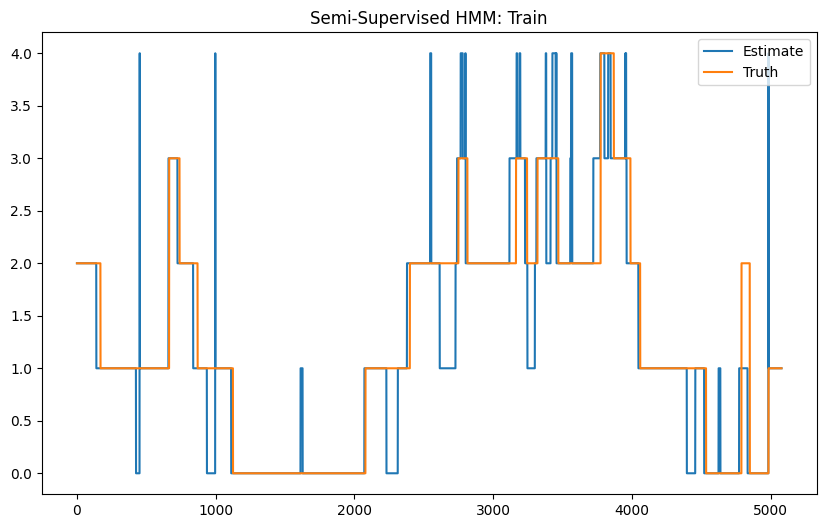

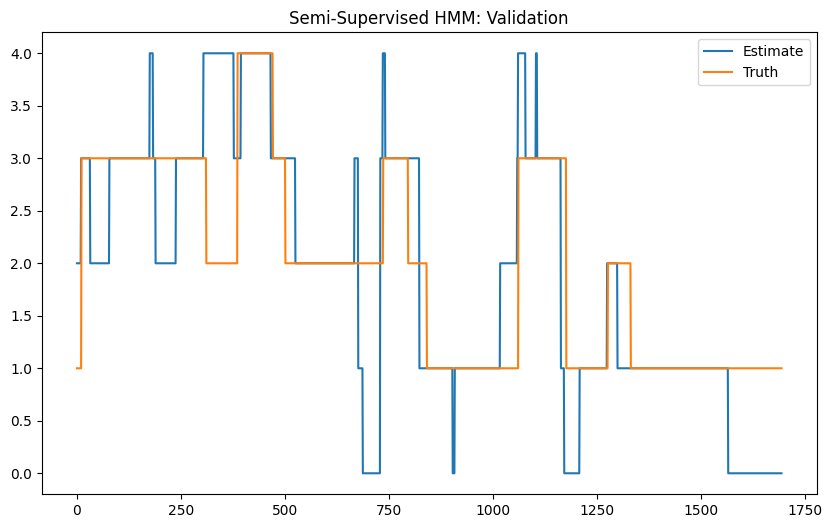

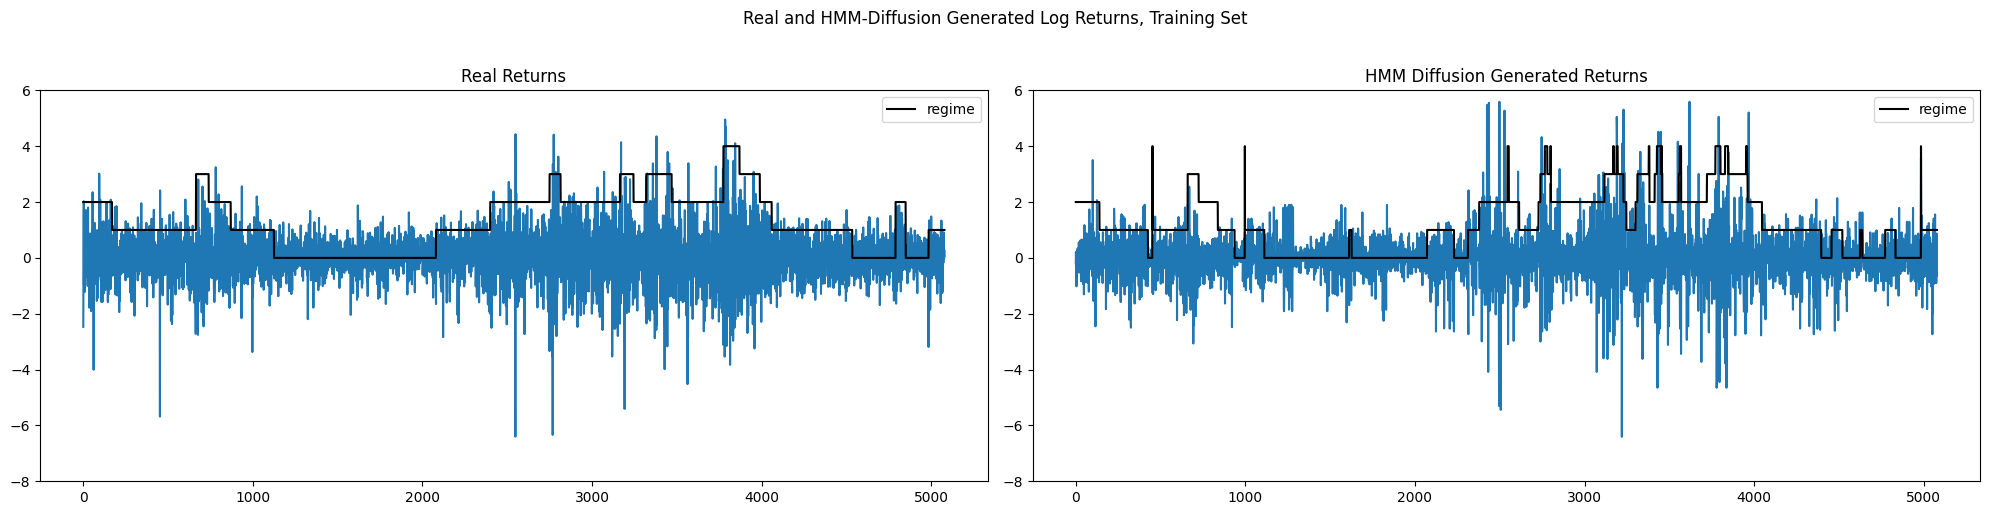

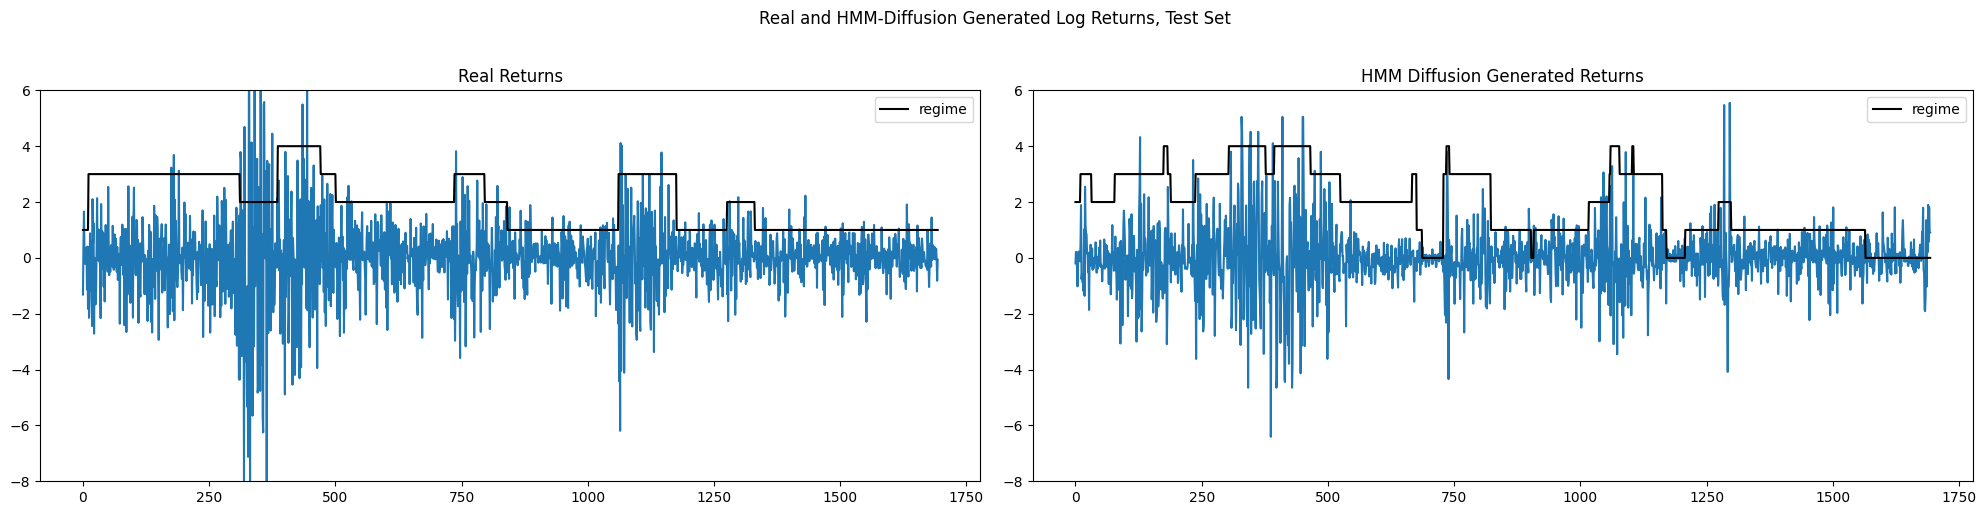

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1345,0.0075,0.0238,0.2508,0.2870
1,1639,0.0192,-0.0038,0.4569,0.4532
2,1510,0.0044,-0.0412,0.9395,0.8118
3,490,-0.0307,0.0279,1.8839,1.7364
4,95,-0.0860,-0.3815,3.6447,3.4311


Test (validation) backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,0,NaN,NaN,NaN,NaN
1,694,0.0202,0.0249,0.4401,0.4458
2,410,-0.0289,-0.0029,3.3034,1.3606
3,505,-0.0527,-0.0485,1.9314,1.3379
4,85,-0.0683,-0.2597,4.7152,5.4775


In [23]:
results["semi_supervised"] = evaluate_variant(
    "semi_supervised", models.fit_semi_supervised_hmm(train_data, N_REGIMES, cfg)
)

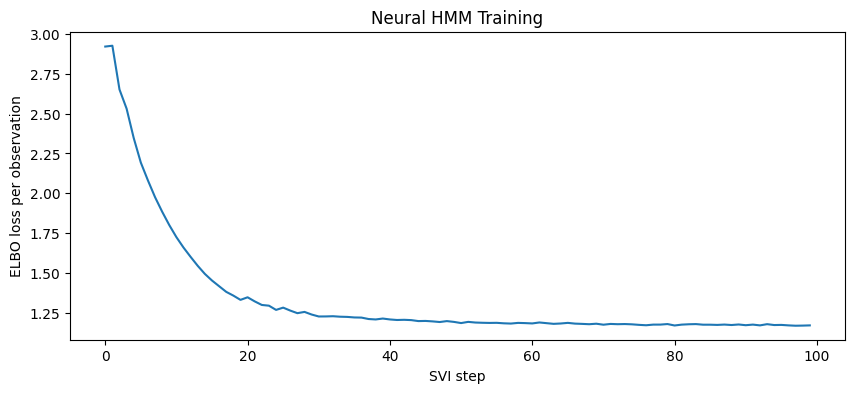

Neural HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9900,0.0030,0.0030,0.0020,0.0020
1,0.0030,0.9900,0.0020,0.0020,0.0020
2,0.0030,0.0030,0.9890,0.0030,0.0030
3,0.0020,0.0020,0.0060,0.9880,0.0020
4,0.0010,0.0010,0.0010,0.0020,0.9960


Emission parameters


,mean,sigma
regime,,
0,0.0084,0.4952
1,0.0144,0.7345
2,0.0053,1.1076
3,-0.0180,1.4170
4,-0.0309,1.4961


100%|██████████| 5079/5079 [00:00<00:00, 100471.02it/s]
5079it [00:00, 102531.51it/s]
100%|██████████| 1694/1694 [00:00<00:00, 105420.80it/s]
1694it [00:00, 106146.84it/s]

Train accuracy  67.61%   top-2  91.38%
Val   accuracy  44.16%   top-2  80.17%


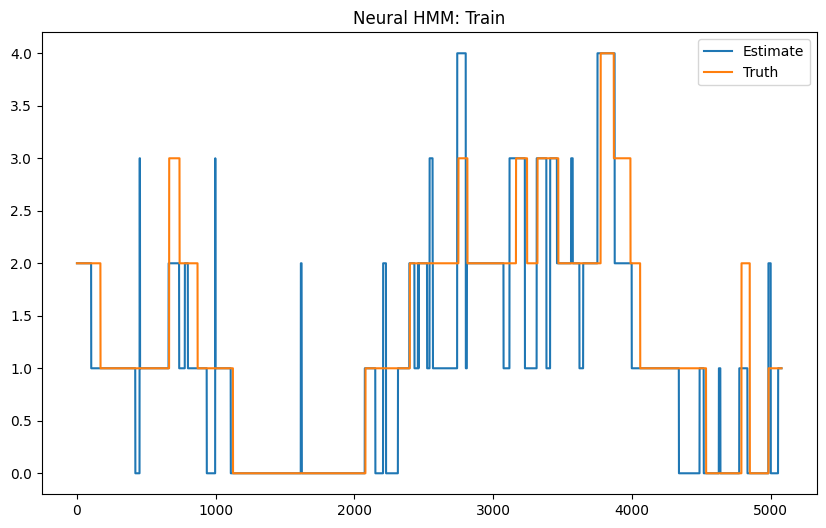

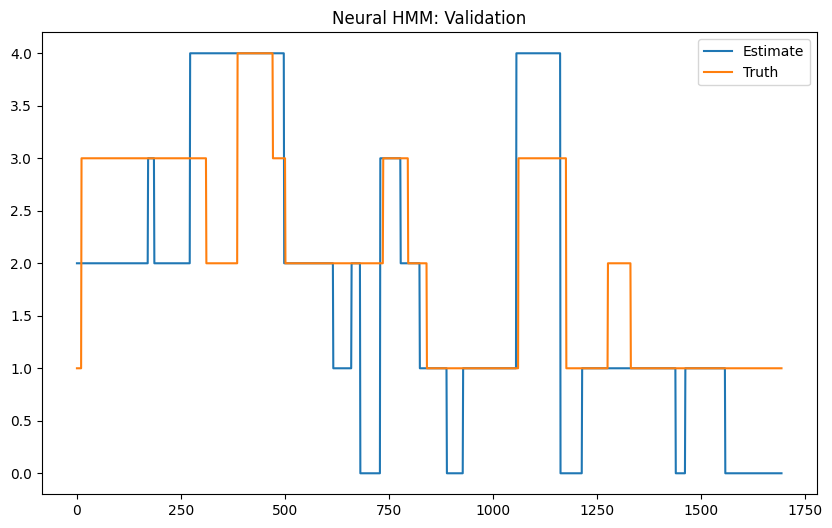

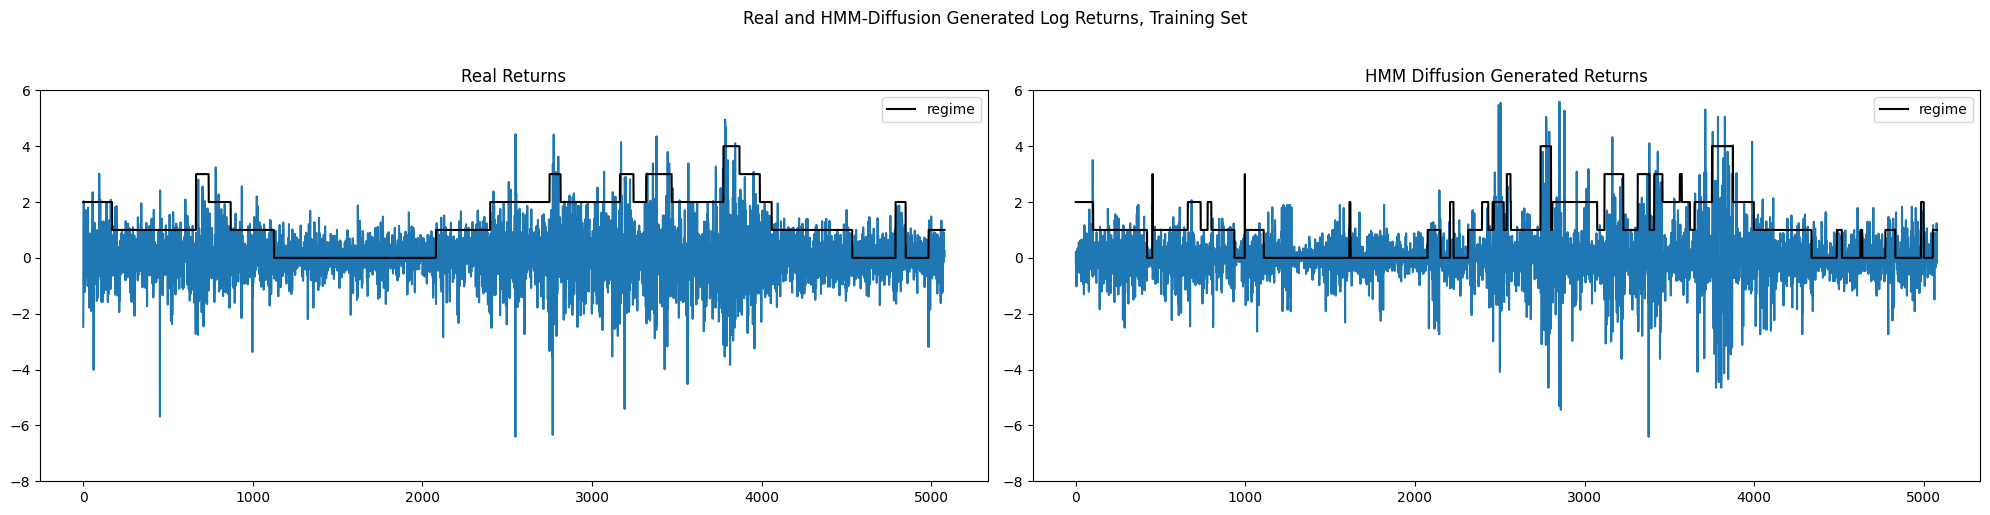

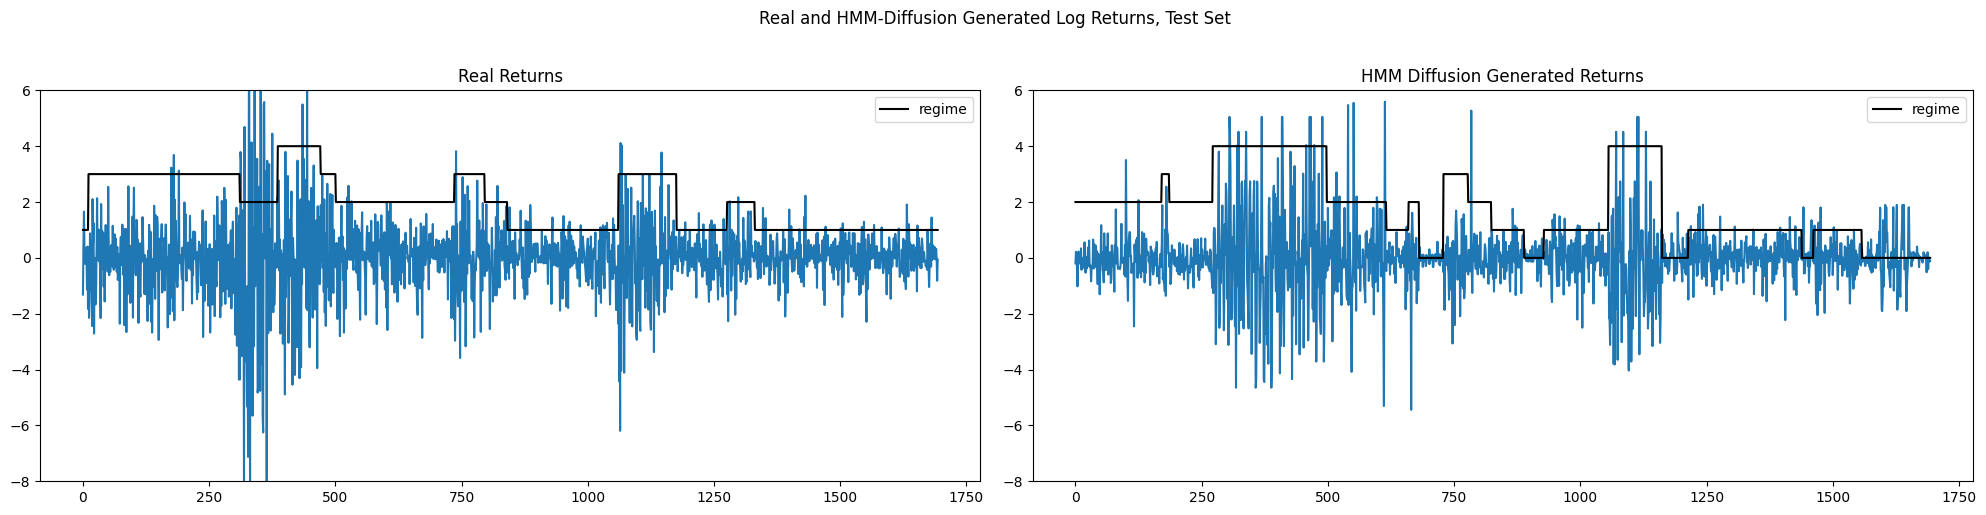

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1345,0.0075,0.0152,0.2508,0.2829
1,1639,0.0192,0.0106,0.4569,0.3804
2,1510,0.0044,-0.0203,0.9395,0.8322
3,490,-0.0307,0.0090,1.8839,1.5940
4,95,-0.0860,-0.2428,3.6447,5.0942


Test (validation) backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,0,NaN,NaN,NaN,NaN
1,694,0.0202,0.0133,0.4401,0.4462
2,410,-0.0289,-0.0669,3.3034,1.8487
3,505,-0.0527,-0.0734,1.9314,1.6498
4,85,-0.0683,0.2183,4.7152,4.7211


In [24]:
neural_fit = models.fit_neural_hmm(train_data, N_REGIMES, cfg)
plots.plot_elbo(neural_fit.diagnostics["elbo_losses"])
results["neural"] = evaluate_variant("neural", neural_fit)

## Results

State-estimation accuracy for all four variants, then the per-regime distributional fit of the generated series. The moment comparison is grouped by the true regime while generated values follow the estimated path. The oracle column stitches along the true path to isolate generator quality.


In [25]:
summary = pd.DataFrame(
    [
        {
            "variant": r["name"],
            "train": r["train_accuracy"],
            f"train_top{TOP_K}": r["train_top_k"],
            "test": r["test_accuracy"],
            f"test_top{TOP_K}": r["test_top_k"],
        }
        for key, r in results.items()
    ]
).set_index("variant")

display(summary.style.format("{:.2%}"))


,train,train_top2,val,val_top2
variant,,,,
Supervised HMM,83.40%,96.69%,63.40%,90.50%
Markov Switching Model,83.23%,96.65%,64.99%,91.15%
Semi-Supervised HMM,80.13%,97.03%,62.87%,89.32%
Neural HMM,67.61%,91.38%,44.16%,80.17%


In [26]:
best_key = summary["test"].idxmax()
best = next(r for r in results.values() if r["name"] == best_key)

oracle_table = stitch.backtest_table(
    train_data.emission.values,
    train_data.regime.values,
    best["oracle"],
    train_data.regime.values,
    N_REGIMES,
)

comparison = pd.DataFrame(
    {
        "real_var": oracle_table["real_var"],
        "oracle_var": oracle_table["gen_var"],
        "hmm_var": best["backtest"]["gen_var"],
        "real_mean": oracle_table["real_mean"],
        "oracle_mean": oracle_table["gen_mean"],
        "hmm_mean": best["backtest"]["gen_mean"],
    }
)

print(f"Per-regime moments, stitched with {best_key}")
display(comparison)

if USING_PLACEHOLDER:
    print(
        "\nThese generated columns come from placeholder resampling, not the diffusion specialists."
    )


Per-regime moments, stitched with Markov Switching Model


,real_var,oracle_var,hmm_var,real_mean,oracle_mean,hmm_mean
regime,,,,,,
0,0.2508,0.2483,0.2774,0.0075,0.0129,0.0077
1,0.4569,0.4651,0.4662,0.0192,0.0039,0.0047
2,0.9395,0.8920,0.9477,0.0044,-0.0336,-0.0214
3,1.8839,1.4224,1.5275,-0.0307,-0.0721,-0.0441
4,3.6447,4.6723,4.2855,-0.0860,0.0959,-0.2315
